In [10]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from aux import plot_phase_space, plot_lattice
from data import parser
from structure import create_lebt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Initial Bunch

In [11]:
B0 = parser()
B0T = rft.Bunch6dT(B0)

M0 = B0T.get_phase_space("%X %xp %Y %yp")

x  = M0[:,0]
xp = M0[:,1]
y  = M0[:,2]
yp = M0[:,3]


#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y, yp, "y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")



N: 15673, Mass: 11174.9 MeV, Energy: 0.182629 MeV, Frequency: 749.48 MHz, Current: 2.89e-06 A, Charge: 6 e


### LEBT


X-X'
emit = 0.0 mm·mrad
beta = 0.0 mm/mrad
alpha = 0.0

Y-Y'
emit = 0.0 mm·mrad
beta = 0.0 mm/mrad
alpha = 0.0

4D
emit4D = 0.0 (mm·mrad)^2
X min/max: -89.99991656404013 -87.81819420315804
Y min/max: -18.53013324678288 19.687516684703088
Z min/max: 821.3099688503635 881.2314518495436


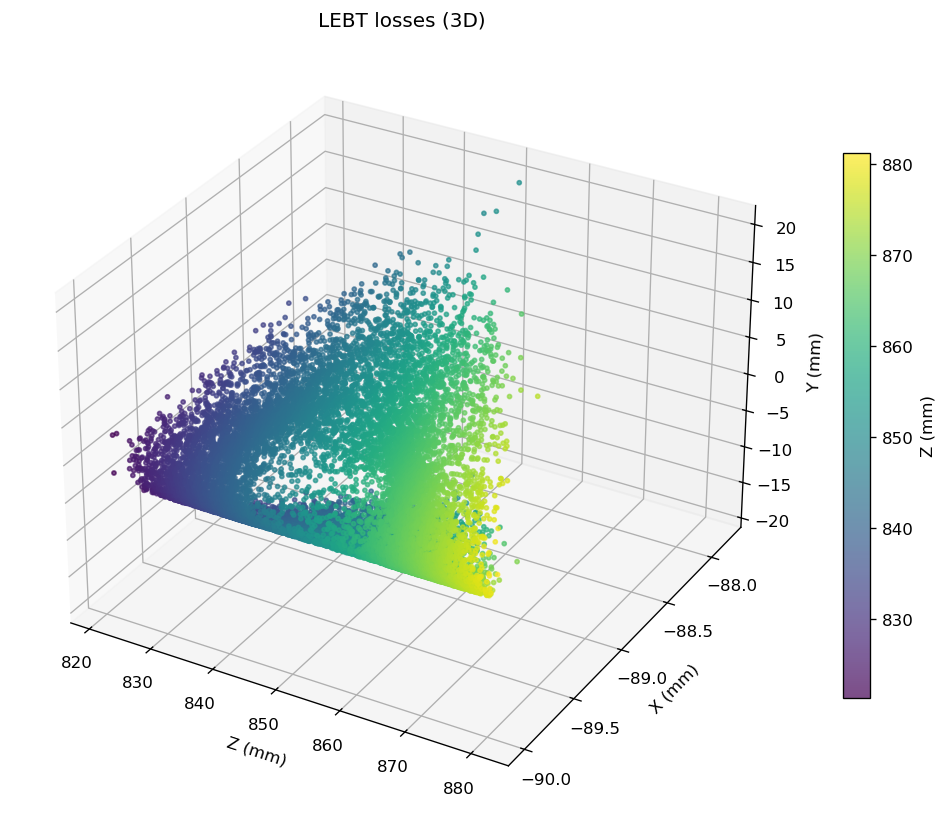

IndexError: index 0 is out of bounds for axis 1 with size 0

In [12]:
lebt = create_lebt(B0T)
lebt.tt_dt_mm = 2


B1 = lebt.track(B0T)
I = B1.get_info()
    
# Beam parameters

print("\nX-X'")
print("emit =", I.emitt_x, "mm·mrad")
print("beta =", I.beta_x, "mm/mrad")
print("alpha =", I.alpha_x)

print("\nY-Y'")
print("emit =", I.emitt_y, "mm·mrad")
print("beta =", I.beta_y, "mm/mrad")
print("alpha =", I.alpha_y)

print("\n4D")
print("emit4D =", I.emitt_4d**2, "(mm·mrad)^2")

# Losses

lost = lebt.get_lost_particles()
X = lost[:, 0]
Y = lost[:, 2]
Z = lost[:, 4]

print("X min/max:", X.min(), X.max())
print("Y min/max:", Y.min(), Y.max())
print("Z min/max:", Z.min(), Z.max())

fig = plt.figure(figsize=(9, 7), dpi=120)
ax3d = fig.add_subplot(111, projection="3d")

sc = ax3d.scatter(
    Z, X, Y,
    c=Z,
    cmap="viridis",
    s=6,
    alpha=0.7
)

ax3d.set_xlabel("Z (mm)")
ax3d.set_ylabel("X (mm)")
ax3d.set_zlabel("Y (mm)")
ax3d.set_title("LEBT losses (3D)")
fig.colorbar(sc, ax=ax3d, shrink=0.7, label="Z (mm)")

plt.tight_layout()
plt.show()

M1 = B1.get_phase_space("%X %xp %Y %yp")

x  = M1[:,0]
xp = M1[:,1]
y  = M1[:,2]
yp = M1[:,3]

#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y,yp,"y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")

T = lebt.get_transport_table("%t %sigma_X %sigma_Y %N %mean_P")

t_rf  = T[:, 0]
mx = T[:, 1]
my = T[:, 2]
N  = T[:, 3]
P = T[:, 4]

# Convert ct to s

m = 12 * 931.494  # MeV/c^2
beta = P / np.sqrt(P**2 + m**2)
s = beta * t_rf   # mm
s = s / 1000      # → m

# Plot rms 

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
color_x = 'tab:blue'
color_y = 'tab:red'
ax.plot(s,  mx,  color=color_x, linewidth=2.5, linestyle='-',  label=r'$\sigma_x$')
ax.plot(s, -mx,  color=color_x, linewidth=1.8, linestyle='-')
ax.plot(s,  my,  color=color_y, linewidth=2.5, linestyle='-',  label=r'$\sigma_y$')
ax.plot(s, -my,  color=color_y, linewidth=1.8, linestyle='-')
ax.set_xlabel('s [m]', fontsize=12)
ax.set_ylabel(r'$\sigma_{x,y}$ [mm]')

ax.set_xlim(0, 4.7)
ax.set_ylim(-max(mx)*1.2, max(mx)*1.2)

ax.legend(loc='upper left') 
ax.grid(True, linestyle='--', alpha=0.4)

plot_lattice(ax)

plt.tight_layout()
plt.show()

#Plot transmission

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, N/N[0]*100, color='tab:red', linewidth=2.5, linestyle='-', label='Transmission')
plt.xlabel('s [m]', fontsize=12)
plt.ylabel('Transmission [%]', fontsize=12)
plt.xlim(0, 4.7) 
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.4)
